In [7]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
seed_list = range(1,6)
scheme_list = ["dringsu2","rrgsu2"]
sw_list =  [120,140,160]

In [9]:
import os

sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for scheme in scheme_list:
        for sw in sw_list:
            for seed in seed_list:
                if sw == 120:
                    outfile = f"../eval_scale_larger_supernode/outfiles/{scheme}_sw{sw}_seed{seed}.out"
                else:
                    outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
                # print(outfile)
                if os.path.exists(outfile):
                    durationlist = list()
                    sizelist = list()
                    startlist = list()
                    with open(outfile,'r') as fr:
                        lines = fr.readlines()
                        for line in lines:
                            tokens = line.split()
                            if tokens[0] == "FCT":
                                durationlist.append(float(tokens[2]))
                                sizelist.append(int(tokens[1]))
                                startlist.append(float(tokens[3]))
                    durationlist.sort()
                    datadict[outfile] = [durationlist,sizelist,startlist]
                    
                    fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_scale_larger_ring.pickle', 'wb') as handle:
    pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

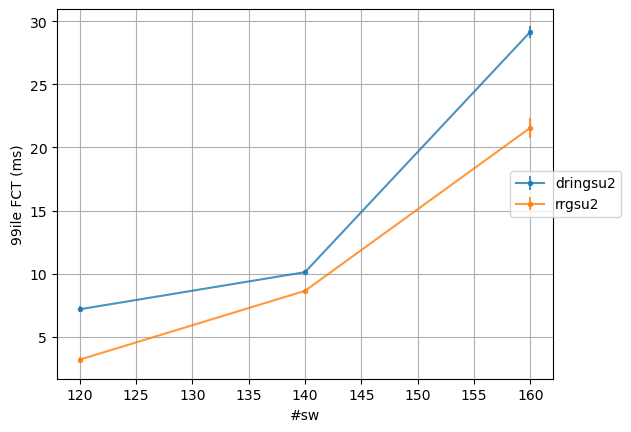

In [11]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        # if cm not in plotdatadict:
        #     plotdatadict[cm] = dict()
        # plotdatadict[cm][outfile] = p99
        plotdatadict[outfile] = p99


markerlist = ['o','x']
for scheme in scheme_list:
    fct_list = list()
    for sw in sw_list:
        fct_list_allseeds = list()
        for seed in seed_list:
            if sw == 120:
                outfile = f"../eval_scale_larger_supernode/outfiles/{scheme}_sw{sw}_seed{seed}.out"
            else:
                outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)
    
    plt.errorbar(sw_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=scheme,alpha=0.8)

plt.xlabel("#sw")
plt.ylabel("99ile FCT (ms)")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))